In [1]:
import torch
import mlflow
import ast
import pandas as pd
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient
import os 
import sys
project_root = os.path.expanduser("~/DLAM-Group6")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from external.xlstm_mixer.xlstm_mixer.models.xlstm_mixer import xLSTMMixer

In [2]:
client = MlflowClient()

df_runs = mlflow.search_runs(
    experiment_names=["single_chunk_forecast", "autoregressive_forecast"]
)

cutoff = pd.Timestamp("2026-08-31", tz="UTC")
summary_table = df_runs.query("(status=='FINISHED') & (start_time >= @cutoff)")#.sort_values(by="metrics.best_val_loss")

In [3]:
def get_differing_params(
    df: pd.DataFrame,
    id_cols: list[str] = ["run_id", "tags.mlflow.runName", "experiment_id"],
    dropna_unique: bool = False,
) -> pd.DataFrame:

    if df.empty:
        return df

    param_cols = [c for c in df.columns if c.startswith("params.")]
    valid_id_cols = [c for c in id_cols if c in df.columns]

    differing_param_cols = []
    for col in param_cols:
        if df[col].nunique(dropna=dropna_unique) > 1:
            differing_param_cols.append(col)

    output_cols = valid_id_cols + differing_param_cols

    return df[output_cols]

def plot_subset(subset, param_of_interest):

    fix, axs = plt.subplots(1,2,figsize=(10, 3))

    for _, run in subset.iterrows():
        run_id = run["run_id"]
        run_name = run["tags.mlflow.runName"]
        run_mse = run["metrics.val_MSE_rescaled"]
        poi_value = run[param_of_interest]
        poi_name = param_of_interest.split(".")[-1]
        history_val = client.get_metric_history(run_id, "val_loss")
        steps_val = [m.step for m in history_val]
        values_val = [m.value for m in history_val]

        history_train = client.get_metric_history(run_id, "train_loss")
        steps_train = [m.step for m in history_train]
        values_train = [m.value for m in history_train]
        
        axs[0].plot(steps_val, values_val, label=f"{round(run_mse,2)}, {poi_name}={poi_value}")
        axs[1].plot(steps_train, values_train, label=f"{round(run_mse,2)}, {poi_name}={poi_value}")

        axs[0].set_xlabel("Epoch")
        axs[1].set_xlabel("Epoch")

        axs[0].set_ylabel("Validation Loss")
        axs[1].set_ylabel("Training Loss")

        axs[0].set_ylim(0.1,0.4)
        axs[1].set_ylim(0,0.4)

        axs[0].legend()
        axs[1].legend()

        axs[0].grid(True)
        axs[1].grid(True)

    return fix, axs

def find_comp_candidates(
    run_id: str,
    df: pd.DataFrame,
    param_column: str | None = None,
) -> pd.DataFrame:
    
    if "run_id" not in df.columns:
        raise ValueError("DataFrame must contain a 'run_id' column.")
    if "experiment_id" not in df.columns:
        raise ValueError("DataFrame must contain an 'experiment_id' column.")

    ref_rows = df[df["run_id"] == run_id]
    if len(ref_rows) == 0:
        raise ValueError(f"run_id '{run_id}' not found in dataframe.")
    if len(ref_rows) > 1:
        raise ValueError(f"run_id '{run_id}' appears multiple times in dataframe.")

    ref_row = ref_rows.iloc[0]

    # Only compare params.* columns
    param_cols = [c for c in df.columns if c.startswith("params.")]
    if not param_cols:
        raise ValueError("No columns starting with 'params.' found in dataframe.")

    if param_column is not None:
        if param_column not in param_cols:
            raise ValueError(
                f"Invalid param_column '{param_column}'. It must be one of: {param_cols}"
            )

    # Restrict to same experiment_id
    same_exp = df["experiment_id"] == ref_row["experiment_id"]

    # Compare params columns, treating NaN == NaN as equal
    def equal_with_nan(col):
        return (df[col] == ref_row[col]) | (df[col].isna() & pd.isna(ref_row[col]))

    if param_column is None:
        # Count how many params columns differ from reference
        equal_matrix = pd.DataFrame({col: equal_with_nan(col) for col in param_cols})
        num_different = (~equal_matrix).sum(axis=1)

        mask = same_exp & (num_different == 1)
    else:
        # Must differ in the chosen column...
        differs_target = ~equal_with_nan(param_column)

        # ...and match in all other params columns
        other_cols = [c for c in param_cols if c != param_column]
        if other_cols:
            equal_others = pd.DataFrame({col: equal_with_nan(col) for col in other_cols}).all(axis=1)
        else:
            equal_others = pd.Series(True, index=df.index)

        mask = same_exp & differs_target & equal_others

    # Usually you do not want to include the reference row itself;
    # it will not match anyway because it differs in 0 params columns.
    return df[mask].copy()

/tmp/ipykernel_2101026/2514120071.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_1.loc[:,"MSE"] = pd.to_numeric(subset_1["metrics.val_MSE_rescaled"])
/tmp/ipykernel_2101026/2514120071.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_2.loc[:,"MSE"] = pd.to_numeric(subset_2["metrics.val_MSE_rescaled"])


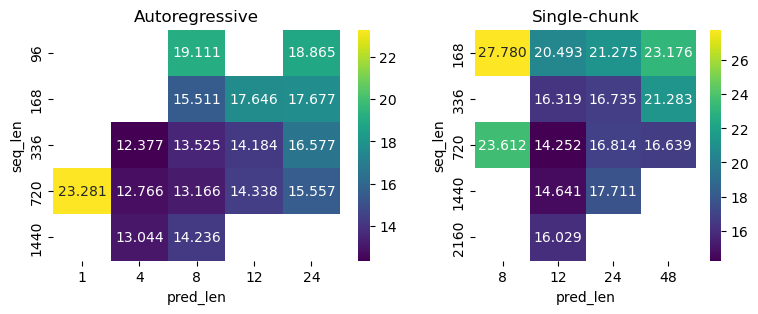

In [18]:
import seaborn as sns
subset_1 = summary_table.query("""experiment_id=='1' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.data.stride`=='12' &\
`params.model.prior`.isna() &\
`params.seed`=='11' &\
`params.shared.criterion`=='Huber'""")

subset_2 = summary_table.query("""experiment_id=='2' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber'""")

subset_1.loc[:,"params.shared.pred_len"] = pd.to_numeric(subset_1["params.shared.pred_len"])
subset_1.loc[:,"params.shared.seq_len"] = pd.to_numeric(subset_1["params.shared.seq_len"])
subset_1.loc[:,"MSE"] = pd.to_numeric(subset_1["metrics.val_MSE_rescaled"])

subset_2.loc[:,"params.shared.pred_len"] = pd.to_numeric(subset_2["params.shared.pred_len"])
subset_2.loc[:,"params.shared.seq_len"] = pd.to_numeric(subset_2["params.shared.seq_len"])
subset_2.loc[:,"MSE"] = pd.to_numeric(subset_2["metrics.val_MSE_rescaled"])

heatmap_df_1=subset_1.pivot_table(columns='params.shared.pred_len', index='params.shared.seq_len', values='metrics.val_MSE_rescaled')
heatmap_df_2=subset_2.pivot_table(columns='params.shared.pred_len', index='params.shared.seq_len', values='metrics.val_MSE_rescaled')

fig, axs = plt.subplots(1, 2, figsize=(9, 3), width_ratios=[1.3,1])
sns.heatmap(heatmap_df_1, annot=True, fmt=".3f", cmap="viridis", ax=axs[0])
axs[0].set_xlabel("pred_len")
axs[0].set_ylabel("seq_len")
axs[0].set_title("Autoregressive")

sns.heatmap(heatmap_df_2, annot=True, fmt=".3f", cmap="viridis", ax=axs[1])
axs[1].set_xlabel("pred_len")
axs[1].set_ylabel("seq_len")
axs[1].set_title("Single-chunk")
plt.show()

Windows seem to have a big impact on performance => finer search worth it before tuning other parameters

## Follow-up-1

### MSE vs Huber

(0.0, 0.8)

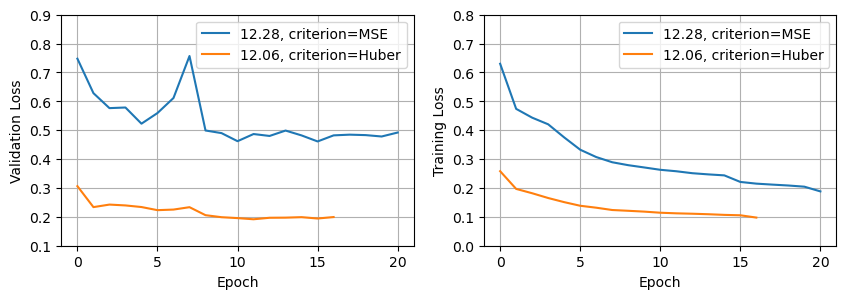

In [5]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`experiment_id`=='1' &\
`params.shared.pred_len`=='4' &\
`params.training.loss_weighted`.isna() &\
`params.data.stride`=='12' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.add_trailing_stats`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
subset
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.shared.criterion")
axs[0].set_ylim(0.1, 0.9)
axs[1].set_ylim(0, 0.8)

### Learning rates

(0.0, 0.5)

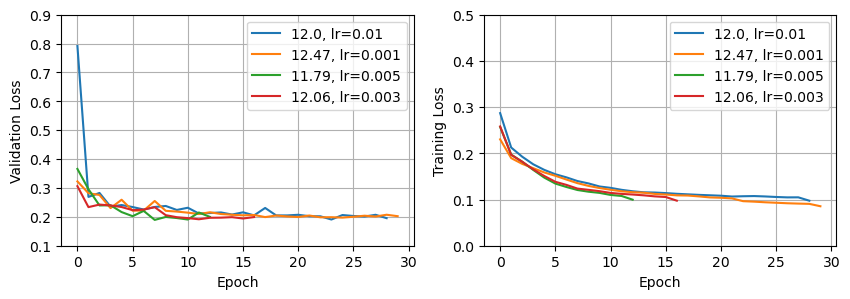

In [6]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.shared.criterion`=='Huber' &\
`params.training.loss_weighted`.isna() &\
`params.data.stride`=='12' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.add_trailing_stats`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.training.optimizer_kwargs.lr")
axs[0].set_ylim(0.1, 0.9)
axs[1].set_ylim(0, 0.5)

Learning rate also has a bigger impact -> tune finely around 0.003

### Stride

(0.0, 0.5)

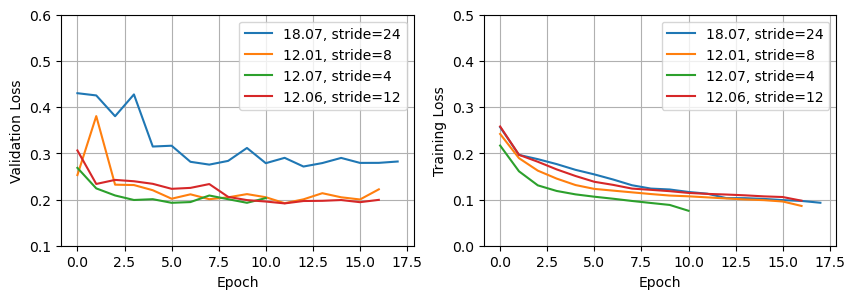

In [8]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.loss_weighted`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.add_trailing_stats`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.data.stride")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

### Weighted loss

(0.0, 0.5)

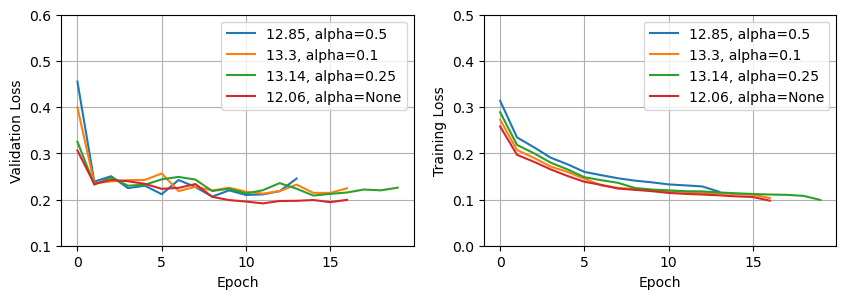

In [10]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.add_trailing_stats`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.training.alpha")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

Advantage of $\alpha=0.5$ not entirely clear because validation loss is more noisy => try both for continuing

### Heads

(0.0, 0.5)

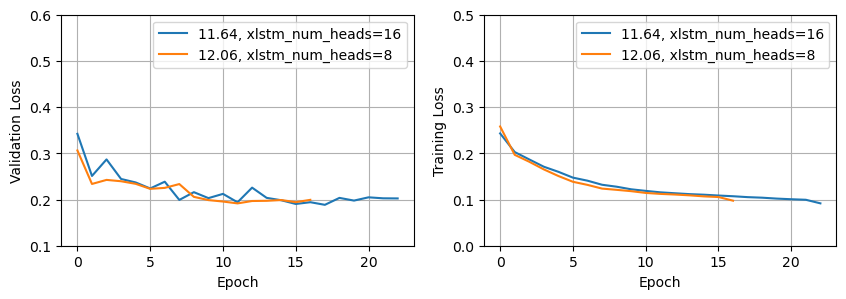

In [12]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.alpha`.isna() &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.add_trailing_stats`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.model.model_kwargs.kwargs.xlstm_num_heads")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

4 heads could be worth trying as well, hard to tell benefit ebcause of noise and early stopping

## Num blocks

(0.0, 0.5)

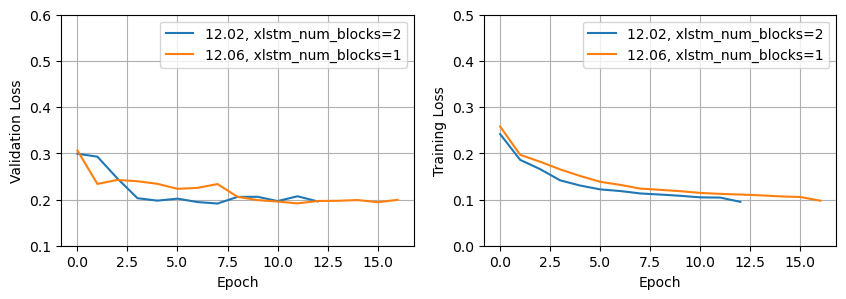

In [13]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.alpha`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.add_trailing_stats`.isna()""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.model.model_kwargs.kwargs.xlstm_num_blocks")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

## Embedding dim

(0.0, 0.5)

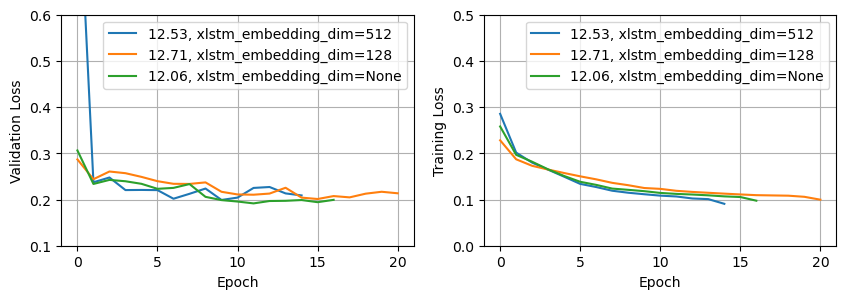

In [14]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.alpha`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.data.add_trailing_stats`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.model.model_kwargs.kwargs.xlstm_embedding_dim")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

(0.0, 0.5)

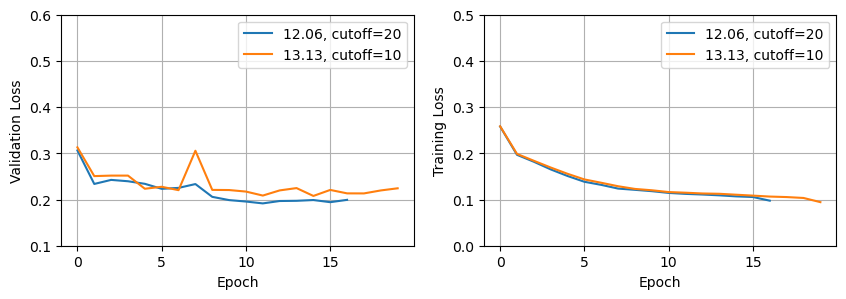

In [16]:
subset = summary_table.query("""`params.model.prior`=='Fourier'""")
fig, axs = plot_subset(subset, param_of_interest="params.model.base_model_kwargs.cutoff")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

## Follow-up 2

## Windows for 3 random seeds

In [27]:
subset = summary_table.query("""experiment_id=='1' &\
`params.shared.pred_len`=='4' &\
`params.training.alpha`.isna() &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.stride`=='12' &\
`params.model.prior`.isna() &\
`params.shared.criterion`=='Huber'""")

In [31]:
subset["params.seed"]

92    11
93    11
95    11
Name: params.seed, dtype: object